In [1]:
import numpy as np
import torch
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Reproducibility (optional)
np.random.seed(0)
torch.manual_seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [2]:
## 1) Load a CIFAR-10 sample

In [3]:
# ImageNet-style preprocessing for pretrained ResNet-18
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

test_set = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)
loader = DataLoader(test_set, batch_size=1, shuffle=True)

img, cifar_label = next(iter(loader))
img = img.to(device)
cifar_label = int(cifar_label.item())

print("CIFAR-10 label (0-9):", cifar_label)
print("Image tensor shape:", tuple(img.shape))

100.0%


CIFAR-10 label (0-9): 6
Image tensor shape: (1, 3, 224, 224)


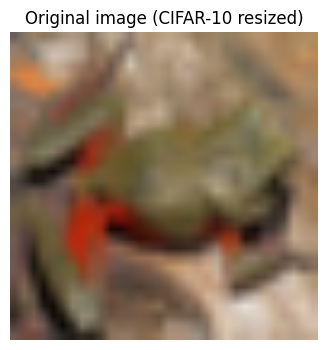

In [4]:
# Helper: denormalize ImageNet-normalized tensors for visualization
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406], device=device).view(1,3,1,1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225], device=device).view(1,3,1,1)

def denorm_imagenet(x):
    """Convert ImageNet-normalized tensor back to [0,1] for plotting."""
    x = x * IMAGENET_STD + IMAGENET_MEAN
    return torch.clamp(x, 0, 1)

def show_tensor_image(x, title=""):
    x = denorm_imagenet(x).detach().cpu()[0]  # (3,H,W)
    x = x.permute(1,2,0).numpy()              # (H,W,3)
    plt.imshow(x)
    plt.title(title)
    plt.axis('off')

plt.figure(figsize=(4,4))
show_tensor_image(img, "Original image (CIFAR-10 resized)")
plt.show()

In [5]:
#We load a pretrained ResNet-18 and move it to the selected device

In [6]:
model = models.resnet18(pretrained=True).to(device)
model.eval()

with torch.no_grad():
    probs = F.softmax(model(img), dim=1)[0]
    clean_pred = int(torch.argmax(probs).item())
    clean_conf = float(torch.max(probs).item())

print("Clean prediction (ImageNet class id):", clean_pred)
print("Clean confidence (max softmax):", clean_conf)

c:\Users\RUSHI\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\RUSHI\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Clean prediction (ImageNet class id): 98
Clean confidence (max softmax): 0.2914637625217438


In [7]:
'''
We represent a candidate as:

[x, y, r, g, b]

 (x, y) = pixel coordinates
 (r, g, b) = color to write at that pixel

### Fitness (non-targeted)
We maximize:

fitness = 1 - P(true_class)

So the attack is “better” when the model becomes less confident in the true class.

### Mutation strategy
We mutate by taking the current best candidate and adding random noise:
- (x, y) moves by up to `step_xy pixels
- (r, g, b) changes by up to `step_rgb

### Constraints
- x ∈ [0, W-1], y ∈ [0, H-1]
- r,g,b ∈ [0,1]
'''


'\nWe represent a candidate as:\n\n[x, y, r, g, b]\n\n (x, y) = pixel coordinates\n (r, g, b) = color to write at that pixel\n\n### Fitness (non-targeted)\nWe maximize:\n\nfitness = 1 - P(true_class)\n\nSo the attack is “better” when the model becomes less confident in the true class.\n\n### Mutation strategy\nWe mutate by taking the current best candidate and adding random noise:\n- (x, y) moves by up to `step_xy pixels\n- (r, g, b) changes by up to `step_rgb\n\n### Constraints\n- x ∈ [0, W-1], y ∈ [0, H-1]\n- r,g,b ∈ [0,1]\n'

In [8]:
def one_pixel_attack_simple(model, img, label, iters=3000, step_xy=12, step_rgb=0.6, verbose=True):
    """
    Simple one-pixel (non-targeted) attack.

    model: torch model
    img:   torch tensor (1,3,H,W) already on device
    label: int (we try to make the model NOT predict this label)

    iters:    number of mutation attempts
    step_xy:  max coordinate change during mutation
    step_rgb: max color change during mutation
    """
    model.eval()
    device = img.device
    _, _, H, W = img.shape

    # Apply candidate to image
    def apply_pixel(candidate):
        x, y, r, g, b = candidate
        x = int(np.clip(round(x), 0, W - 1))
        y = int(np.clip(round(y), 0, H - 1))

        tmp = img.clone()
        tmp[0, :, y, x] = torch.tensor([r, g, b], device=device, dtype=tmp.dtype)
        return tmp

    # Fitness: maximize (1 - P(label))
    @torch.no_grad()
    def fitness(candidate):
        tmp = apply_pixel(candidate)
        probs = F.softmax(model(tmp), dim=1)[0]
        p_label = float(probs[label].item())
        pred = int(torch.argmax(probs).item())
        return (1.0 - p_label), pred, p_label

    # Initialize a random candidate
    best = np.array([
        np.random.uniform(0, W - 1),  # x
        np.random.uniform(0, H - 1),  # y
        np.random.uniform(0, 1),      # r
        np.random.uniform(0, 1),      # g
        np.random.uniform(0, 1)       # b
    ], dtype=np.float32)

    best_fit, best_pred, best_p = fitness(best)

    for t in range(1, iters + 1):
        # --- MUTATION STRATEGY ---
        trial = best.copy()
        trial[0] += np.random.uniform(-step_xy, step_xy)          # x mutation
        trial[1] += np.random.uniform(-step_xy, step_xy)          # y mutation
        trial[2:] += np.random.uniform(-step_rgb, step_rgb, 3)    # rgb mutation

        # --- CONSTRAINT HANDLING ---
        trial[0] = np.clip(trial[0], 0, W - 1)
        trial[1] = np.clip(trial[1], 0, H - 1)
        trial[2:] = np.clip(trial[2:], 0.0, 1.0)

        # --- FITNESS EVALUATION ---
        f, pred, p = fitness(trial)

        # Keep if improved
        if f > best_fit:
            best, best_fit, best_pred, best_p = trial, f, pred, p

        # Success if the model changed its prediction away from label
        if pred != label:
            if verbose:
                print(f"Success at step {t}: P(label) dropped to {best_p:.4f}")
            return best, t, True

        # Progress logging
        if verbose and t % 300 == 0:
            print(f"Step {t}: best P(label)={best_p:.4f}, best fitness={best_fit:.4f}")

    if verbose:
        print("Not successful within iters; returning best found.")
    return best, iters, False

In [9]:
# We attack the model's own clean prediction so success means: prediction changes.
target_label_for_attack = clean_pred

best_candidate, steps_used, success = one_pixel_attack_simple(
    model, img, target_label_for_attack,
    iters=3000, step_xy=12, step_rgb=0.6, verbose=True
)

print("\nAttack success:", success)
print("Steps used:", steps_used)
print("Best candidate [x, y, r, g, b]:", best_candidate)

Success at step 2: P(label) dropped to 0.1236

Attack success: True
Steps used: 2
Best candidate [x, y, r, g, b]: [132.88828 158.6828    1.        1.        0.     ]


In [10]:
# Build adversarial image from the best candidate
x, y, r, g, b = best_candidate
_, _, H, W = img.shape
x_i = int(np.clip(round(x), 0, W - 1))
y_i = int(np.clip(round(y), 0, H - 1))

adv_img = img.clone()
adv_img[0, :, y_i, x_i] = torch.tensor([r, g, b], device=device, dtype=adv_img.dtype)

with torch.no_grad():
    clean_probs = F.softmax(model(img), dim=1)[0]
    adv_probs = F.softmax(model(adv_img), dim=1)[0]

clean_pred2 = int(torch.argmax(clean_probs).item())
adv_pred2   = int(torch.argmax(adv_probs).item())

print("Clean pred:", clean_pred2, "| max prob:", float(torch.max(clean_probs).item()))
print("Adv pred:  ", adv_pred2,   "| max prob:", float(torch.max(adv_probs).item()))
print("Pixel changed at (x,y)=", (x_i, y_i))

Clean pred: 98 | max prob: 0.2914637625217438
Adv pred:   491 | max prob: 0.12484428286552429
Pixel changed at (x,y)= (133, 159)


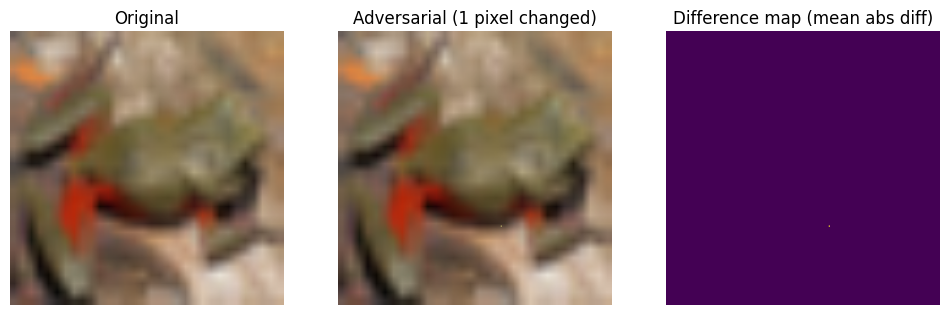

In [11]:
# Difference map (absolute difference)
diff = torch.abs(denorm_imagenet(adv_img) - denorm_imagenet(img))  # (1,3,H,W)
diff_gray = diff.mean(dim=1, keepdim=True)                         # (1,1,H,W)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
show_tensor_image(img, "Original")

plt.subplot(1,3,2)
show_tensor_image(adv_img, "Adversarial (1 pixel changed)")

plt.subplot(1,3,3)
d = diff_gray.detach().cpu()[0,0].numpy()
plt.imshow(d)
plt.title("Difference map (mean abs diff)")
plt.axis('off')

plt.show()